In [2]:
import os
from PIL import Image, ImageDraw
from ultralytics import YOLO
import numpy as np

# 載入 yolov8 模型
yolo = YOLO('./yolov8m.pt')

filename = './1_0_0_20161219140623097.jpg.chip.jpg'
# 获取文件的绝对路径
abs_filename = os.path.abspath(filename)

if filename.endswith('.jpg') and 'chip' in abs_filename:
    # 解析檔案名稱，假設檔案名稱格式為 "年齡_性別_其他參數.jpg.chip"
    parts = filename.split('_')

    # 提取年齡、性別等相關信息
    age = parts[0]
    gender = parts[1]
    # 可以根據實際情況進一步提取其他參數

    # 構建標註信息
    annotation = {'age': age, 'gender': gender}

   # 讀取圖片
    print(f"Opening image: {abs_filename}")
    img = Image.open(filename)
    print(f"Image opened successfully.")

    # 使用 YOLO 模型進行物件檢測
    print("Predicting with YOLO model.")
    results = yolo.predict(img)
    print("Prediction completed.")

    # 在圖片上繪製人臉框
    draw = ImageDraw.Draw(img)
    for detection in results:
        bbox = detection['box']
        draw.rectangle(bbox, outline="red", width=2)

    # 保存標註後的圖片
    annotated_image_path = f"annotated_{filename}"
    img.save(annotated_image_path)

    # 保存標籤檔案
    label_file_path = f"{os.path.splitext(filename)[0]}.txt"
    with open(label_file_path, 'w') as f:
        for detection in results:
            bbox = detection['box']
            class_id = detection['class']
            x, y, w, h = bbox
            # 將相對座標轉換為相對尺寸
            x, w = x + w / 2, w
            y, h = y + h / 2, h
            # 寫入標籤信息
            label_line = f"{class_id} {x} {y} {w} {h}\n"
            f.write(label_line)

print("自動標註完成！")

Opening image: d:\Data\112_1_碩班_深度學習\課程\project2\123\1_0_0_20161219140623097.jpg.chip.jpg
Image opened successfully.
Predicting with YOLO model.



0: 640x640 1 person, 398.1ms
Speed: 3.1ms preprocess, 398.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


Prediction completed.


IndexError: too many indices for tensor of dimension 2

In [9]:
result_img

array([[[ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255],
        ...,
        [ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255]],

       [[ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255],
        ...,
        [ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255]],

       [[ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255],
        ...,
        [ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255]],

       ...,

       [[ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255],
        ...,
        [ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255]],

       [[ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255],
        ...,
        [ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255]],

       [[ 56,  56, 255],
        [ 56,  56, 255],
        [ 56,  56, 255],
        ...,
        [ 56,  56, 255],
        [ 56,  56, 255],
        [145, 133, 238]]

In [10]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
keys: ['boxes']
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58:

In [11]:
results[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [12]:
results[0].boxes.cls

tensor([0.])

In [13]:
results[0].boxes.data

tensor([[  0.7672,   0.0000, 198.7728, 198.0487,   0.5121,   0.0000]])

In [14]:
results[0].boxes.xyxy

tensor([[  0.7672,   0.0000, 198.7728, 198.0487]])

In [9]:
# 在圖片上繪製人臉框
draw = ImageDraw.Draw(img)

# 保存 bbox 資訊的列表
bbox_list = []

for detection in results.xyxy[0].numpy():
    bbox = detection[0:4].tolist()
    class_id = int(detection[5])
    x, y, w, h = bbox
    # 將相對座標轉換為相對尺寸
    x, w = x + w / 2, w
    y, h = y + h / 2, h
    # 寫入標籤信息
    label_line = f"{class_id} {x} {y} {w} {h}\n"
    bbox_list.append(label_line)

    # 繪製 bbox
    draw.rectangle(bbox, outline="red", width=2)

# 保存標註後的圖片
annotated_image_path = f"annotated_{filename}"
img.save(annotated_image_path)

AttributeError: 'list' object has no attribute 'xyxy'

In [16]:
from PIL import Image, ImageDraw
from ultralytics import YOLO

# 載入 yolov8 模型
yolo = YOLO('./yolov8m.pt')

filename = './1_0_0_20161219140623097.jpg.chip.jpg'
# 获取文件的绝对路径
abs_filename = os.path.abspath(filename)

if filename.endswith('.jpg') and 'chip' in abs_filename:
    # 解析檔案名稱，假設檔案名稱格式為 "年齡_性別_其他參數.jpg.chip"
    parts = filename.split('_')

    # 提取年齡、性別等相關信息
    age = parts[0]
    gender = parts[1]
    # 可以根據實際情況進一步提取其他參數

    # 構建標註信息
    annotation = {'age': age, 'gender': gender}

    # 讀取圖片
    print(f"Opening image: {abs_filename}")
    img = Image.open(filename)
    print(f"Image opened successfully.")

    # 使用 YOLO 模型進行物件檢測
    print("Predicting with YOLO model.")
    results = yolo.predict(img)
    print("Prediction completed.")

    # 在圖片上繪製人臉框
    draw = ImageDraw.Draw(img)

    # 保存 bbox 資訊的列表
    bbox_list = []

    for detection in results[0].xyxy.numpy():
        bbox = detection[0:4].tolist()
        class_id = int(detection[5])
        x, y, w, h = bbox
        # 將相對座標轉換為相對尺寸
        x, w = x + w / 2, w
        y, h = y + h / 2, h
        # 寫入標籤信息
        label_line = f"{class_id} {x} {y} {w} {h}\n"
        bbox_list.append(label_line)

        # 繪製 bbox
        draw.rectangle(bbox, outline="red", width=2)

    # 保存標註後的圖片
    annotated_image_path = f"annotated_{filename}"
    img.save(annotated_image_path)

    # 保存 bbox 信息到文件
    bbox_file_path = f"bbox_info_{filename}.txt"
    with open(bbox_file_path, 'w') as bbox_file:
        bbox_file.writelines(bbox_list)

    print(f"自動標註完成！Bbox information saved to {bbox_file_path}")


Opening image: d:\Data\112_1_碩班_深度學習\課程\project2\123\1_0_0_20161219140623097.jpg.chip.jpg
Image opened successfully.
Predicting with YOLO model.



0: 640x640 1 person, 419.3ms
Speed: 4.0ms preprocess, 419.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


Prediction completed.


AttributeError: 'Results' object has no attribute 'xyxy'. See valid attributes below.

    A class for storing and manipulating inference results.

    Args:
        orig_img (numpy.ndarray): The original image as a numpy array.
        path (str): The path to the image file.
        names (dict): A dictionary of class names.
        boxes (torch.tensor, optional): A 2D tensor of bounding box coordinates for each detection.
        masks (torch.tensor, optional): A 3D tensor of detection masks, where each mask is a binary image.
        probs (torch.tensor, optional): A 1D tensor of probabilities of each class for classification task.
        keypoints (List[List[float]], optional): A list of detected keypoints for each object.

    Attributes:
        orig_img (numpy.ndarray): The original image as a numpy array.
        orig_shape (tuple): The original image shape in (height, width) format.
        boxes (Boxes, optional): A Boxes object containing the detection bounding boxes.
     

# 切割測試

In [36]:
import os
from PIL import Image, ImageDraw
from ultralytics import YOLO
import numpy as np

# 載入 yolov8 模型
yolo = YOLO('./yolov8m.pt')

filename = './60_1_0_20170110141405608.jpg.chip.jpg'
# 获取文件的绝对路径
abs_filename = os.path.abspath(filename)

In [37]:
parts = filename.split('_')

# 提取年齡、性別等相關信息
age = parts[0]
gender = parts[1]
# 可以根據實際情況進一步提取其他參數

# 構建標註信息
annotation = {'age': age, 'gender': gender}

# 讀取圖片
print(f"Opening image: {abs_filename}")
img = Image.open(filename)
print(f"Image opened successfully.")

Opening image: d:\Data\112_1_碩班_深度學習\課程\project2\123\60_1_0_20170110141405608.jpg.chip.jpg
Image opened successfully.


Predicting with YOLO model.



0: 640x640 1 person, 422.7ms
Speed: 3.0ms preprocess, 422.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


Prediction completed.


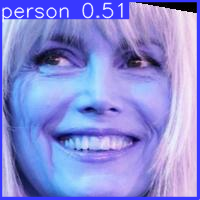

In [33]:
# 使用 YOLO 模型進行物件檢測
print("Predicting with YOLO model.")
results = yolo.predict(img)
print("Prediction completed.")
result_img = results[0].plot()
Image.fromarray(result_img)

In [34]:
# 在圖片上繪製人臉框
draw = ImageDraw.Draw(img)

# 保存 bbox 資訊的列表
bbox_list = []

for detection in results[0].boxes.data.numpy():
    bbox = detection[0:4].tolist()
    class_id = int(detection[5])
    x, y, w, h = bbox
    # 將相對座標轉換為相對尺寸
    x, w = x + w / 2, w
    y, h = y + h / 2, h
    # 寫入標籤信息
    label_line = f"{class_id} {x} {y} {w} {h}\n"
    bbox_list.append(label_line)

    # 繪製 bbox
    draw.rectangle(bbox, outline="red", width=2)

# 保存標註後的圖片
annotated_image_path = f"annotated_{os.path.basename(filename)}"
img.save(annotated_image_path)


In [41]:
# 使用 YOLO 模型進行物件檢測
print("Predicting with YOLO model.")
results = yolo.predict(img)
print("Prediction completed.")

# 保存 bbox 資訊的列表
bbox_list = []

# 在圖片上繪製人臉框
draw = ImageDraw.Draw(img)

# 確保 results 是 Results 對象
if not isinstance(results, YOLO.Results):
    raise ValueError("yolo.predict should return a YOLO.Results object.")

for detection in results.xyxy[0].numpy():
    bbox = detection[0:4].tolist()
    class_id = int(detection[5])
    x, y, w, h = bbox
    # 將相對座標轉換為相對尺寸
    x, w = x + w / 2, w
    y, h = y + h / 2, h
    # 寫入標籤信息
    label_line = f"{class_id} {x} {y} {w} {h}\n"
    bbox_list.append(label_line)

    # 繪製 bbox
    draw.rectangle(bbox, outline="red", width=2)

# 保存標註後的圖片
annotated_image_path = f"annotated_{os.path.basename(filename)}"
img.save(annotated_image_path)

# 保存標註資訊到檔案
label_file_path = f"{os.path.splitext(filename)[0]}.txt"
with open(label_file_path, 'w') as f:
    f.writelines(bbox_list)

print("自動標註完成！")


Predicting with YOLO model.


0: 640x640 1 person, 415.5ms
Speed: 4.4ms preprocess, 415.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


Prediction completed.


AttributeError: type object 'YOLO' has no attribute 'Results'

In [54]:
import os
from PIL import Image, ImageDraw
from ultralytics import YOLO
import numpy as np

# 載入 yolov8 模型
yolo = YOLO('./yolov8m.pt')

filename = './1_0_0_20161219140623097.jpg.chip.jpg'
# 获取文件的绝对路径
abs_filename = os.path.abspath(filename)
parts = filename.split('_')

# 提取年齡、性別等相關信息
age = parts[0]
# 去掉前面的 "./"
age = age[2:]

gender = parts[1]
# 可以根據實際情況進一步提取其他參數

# 構建標註信息
annotation = {'age': age, 'gender': gender}

# 讀取圖片
print(f"1-1.Opening image: {abs_filename}")
img = Image.open(filename)
print(f"1-2.Image opened successfully.")

# 使用 YOLO 模型進行物件檢測
print("2-1.Predicting with YOLO model.")
results = yolo.predict(img)
print("2-2.Prediction completed.")

# 保存 bbox 資訊的列表
bbox_list = []

# 在圖片上繪製人臉框
draw = ImageDraw.Draw(img)

# 在圖片上繪製人臉框
draw = ImageDraw.Draw(img)

# 保存 bbox 資訊的列表
bbox_list = []

for detection in results[0].boxes.data.numpy():
    bbox = detection[0:4].tolist()
    class_id = int(detection[5])
    x, y, w, h = bbox
    # 將相對座標轉換為相對尺寸
    x, w = x + w / 2, w
    y, h = y + h / 2, h
    # 寫入標籤信息
    label_line = f"{class_id} {x} {y} {w} {h} {age} {gender}\n"
    bbox_list.append(label_line)

    # 繪製 bbox
    draw.rectangle(bbox, outline="red", width=2)

# 保存標註後的圖片
print("3-1.Save img.")
annotated_image_path = f"annotated_{os.path.basename(filename)}"
img.save(annotated_image_path)
print("3-2.Save img completed.")

# 保存標籤文件
print("4-1.Save label.")
label_file_path = f"{os.path.splitext(filename)[0]}.txt"
with open(label_file_path, 'w') as f:
    for detection in results[0].boxes.data.numpy():
        bbox = detection[0:4].tolist()
        class_id = int(detection[5])
        x, y, w, h = bbox
        # 將相對座標轉換為相對尺寸
        x, w = x + w / 2, w
        y, h = y + h / 2, h
        # 寫入標籤信息
        id = str(class_id) + "_" + gender + "_" + age
        label_line = f"{id} {x} {y} {w} {h}"
        f.write(label_line)
print("4-2.Save label completed.")


print("自動標註完成！")


1-1.Opening image: d:\Data\112_1_碩班_深度學習\課程\project2\123\1_0_0_20161219140623097.jpg.chip.jpg
1-2.Image opened successfully.
2-1.Predicting with YOLO model.



0: 640x640 1 person, 393.0ms
Speed: 4.3ms preprocess, 393.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


2-2.Prediction completed.
3-1.Save img.
3-2.Save img completed.
4-1.Save label.
4-2.Save label completed.
自動標註完成！


In [61]:
import os
from PIL import Image, ImageDraw
from ultralytics import YOLO
import numpy as np

# 載入 yolov8 模型
yolo = YOLO('./yolov8m.pt')

# 資料夾路徑
input_folder_path = './dataset/'
output_folder_path = './pre/'

# 獲取資料夾中所有檔案
files = os.listdir(input_folder_path)

# 迴圈處理每個檔案
for filename in files:
    # 檔案完整路徑
    input_file_path = os.path.join(input_folder_path, filename)

    # 提取年齡、性別等相關信息
    parts = filename.split('_')
    age = parts[0]
    gender = parts[1]

    # 構建標註信息
    annotation = {'age': age, 'gender': gender}

    # 讀取圖片
    print(f"1-1.Opening image: {input_file_path}")
    img = Image.open(input_file_path)
    print(f"1-2.Image opened successfully.")

    # 使用 YOLO 模型進行物件檢測
    print("2-1.Predicting with YOLO model.")
    results = yolo.predict(img)
    print("2-2.Prediction completed.")

    # 保存 bbox 資訊的列表
    bbox_list = []

    # 在圖片上繪製人臉框
    draw = ImageDraw.Draw(img)

    for detection in results[0].boxes.data.numpy():
        bbox = detection[0:4].tolist()
        class_id = int(detection[5])
        x, y, w, h = bbox
        # 將相對座標轉換為相對尺寸
        x, w = x + w / 2, w
        y, h = y + h / 2, h
        # 寫入標籤信息
        label_line = f"{class_id} {x} {y} {w} {h} {age} {gender}\n"
        bbox_list.append(label_line)

        # 繪製 bbox
        draw.rectangle(bbox, outline="red", width=2)

    # 保存標註後的圖片
    output_annotated_image_path = os.path.join(output_folder_path, f"{os.path.basename(filename)}")
    print(f"3.Save img: {output_annotated_image_path}")
    img.save(output_annotated_image_path)

    # 保存標籤文件
    output_label_file_path = os.path.join(output_folder_path, f"{os.path.splitext(filename)[0]}.txt")
    with open(output_label_file_path, 'w') as f:
        for detection in results[0].boxes.data.numpy():
            bbox = detection[0:4].tolist()
            class_id = int(detection[5])
            x, y, w, h = bbox
            # 將相對座標轉換為相對尺寸
            x, w = x + w / 2, w
            y, h = y + h / 2, h
            # 寫入標籤信息
            id = str(class_id) + "_" + gender + "_" + age
            label_line = f"{id} {x} {y} {w} {h}\n"
            f.write(label_line)

    print("Label file saved./n-------------------------------")


1-1.Opening image: ./dataset/1_0_0_20161219140623097.jpg.chip.jpg
1-2.Image opened successfully.
2-1.Predicting with YOLO model.



0: 640x640 1 person, 400.0ms
Speed: 3.4ms preprocess, 400.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)



2-2.Prediction completed.
3.Save img: ./pre/1_0_0_20161219140623097.jpg.chip.jpg
Label file saved./n-------------------------------
1-1.Opening image: ./dataset/60_1_0_20170110141405608.jpg.chip.jpg
1-2.Image opened successfully.
2-1.Predicting with YOLO model.


0: 640x640 1 person, 443.0ms
Speed: 3.1ms preprocess, 443.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


2-2.Prediction completed.
3.Save img: ./pre/60_1_0_20170110141405608.jpg.chip.jpg
Label file saved./n-------------------------------
